# Préparation de l'environement

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

## Chargeement des datasets

In [2]:
# Chargement (adapte le chemin selon où tu as mis les fichiers)
orders = pd.read_csv('/Users/GermainMbila/Documents/Projets/Projets 2026/Dataset Olist (Retail:Marketing)/olist_orders_dataset.csv')
items = pd.read_csv('/Users/GermainMbila/Documents/Projets/Projets 2026/Dataset Olist (Retail:Marketing)/olist_order_items_dataset.csv')
customers = pd.read_csv('/Users/GermainMbila/Documents/Projets/Projets 2026/Dataset Olist (Retail:Marketing)/olist_customers_dataset.csv')

# Visualisation des 5 premières lignes
print(orders.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [3]:
# Conversion des colonnes de dates
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date', 
                'order_estimated_delivery_date']

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Vérification des types
print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


## Étape 3 : La première Analyse "Marketing/Finance"

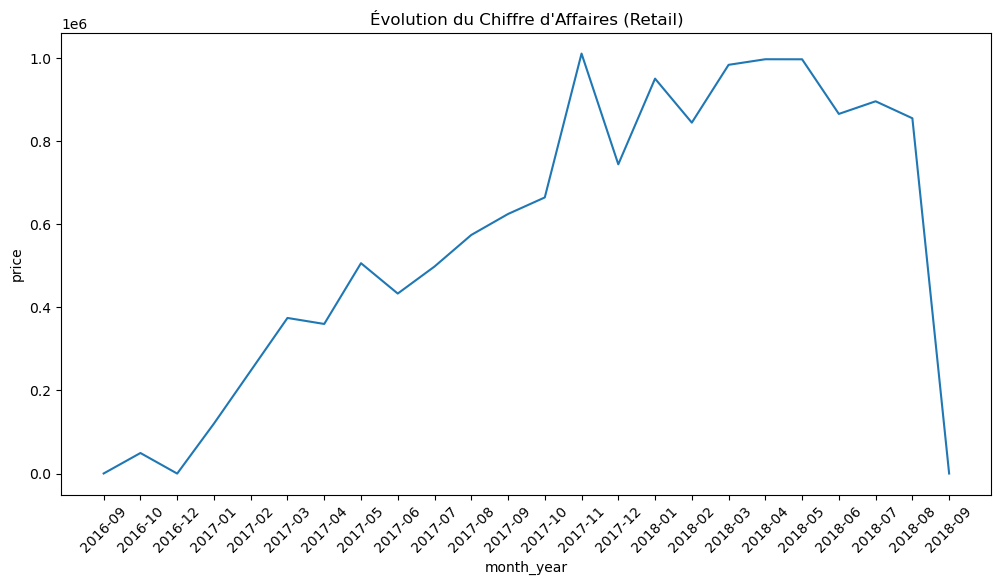

In [4]:
# 1. Fusionner les commandes avec les items pour avoir les prix
order_details = pd.merge(orders, items, on='order_id')

# 2. Créer une colonne "Mois-Année" pour le groupement
order_details['month_year'] = order_details['order_purchase_timestamp'].dt.to_period('M')

# 3. Calculer le CA mensuel
monthly_revenue = order_details.groupby('month_year')['price'].sum().reset_index()

# 4. Visualisation rapide
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_revenue, x=monthly_revenue['month_year'].astype(str), y='price')
plt.xticks(rotation=45)
plt.title('Évolution du Chiffre d\'Affaires (Retail)')
plt.show()

## Quels sont les 5 États brésiliens (customer_state) qui génèrent le plus de chiffre d'affaires ?

In [5]:
# 1. Fusionner les commandes détailer avec les consommateur pour avoir informations des consmateurs
customers_details = pd.merge(order_details, customers, on='customer_id')

In [6]:
customers_details.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,month_year,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [11]:
# 2. Créer une colonne "Mois-Année" pour le groupement
customers_details['month_year'] = customers_details['order_purchase_timestamp'].dt.to_period('M')

# 3. Création du tableau des états consomateurs
state_revenue = customers_details.groupby('customer_state')['price'].sum().reset_index()

state_revenue.sort_values(by='price', ascending = False)

,customer_state,price
25,SP,5202955.05
18,RJ,1824092.67
10,MG,1585308.03
22,RS,750304.02
17,PR,683083.76
23,SC,520553.34
4,BA,511349.99
6,DF,302603.94
8,GO,294591.95
7,ES,275037.31


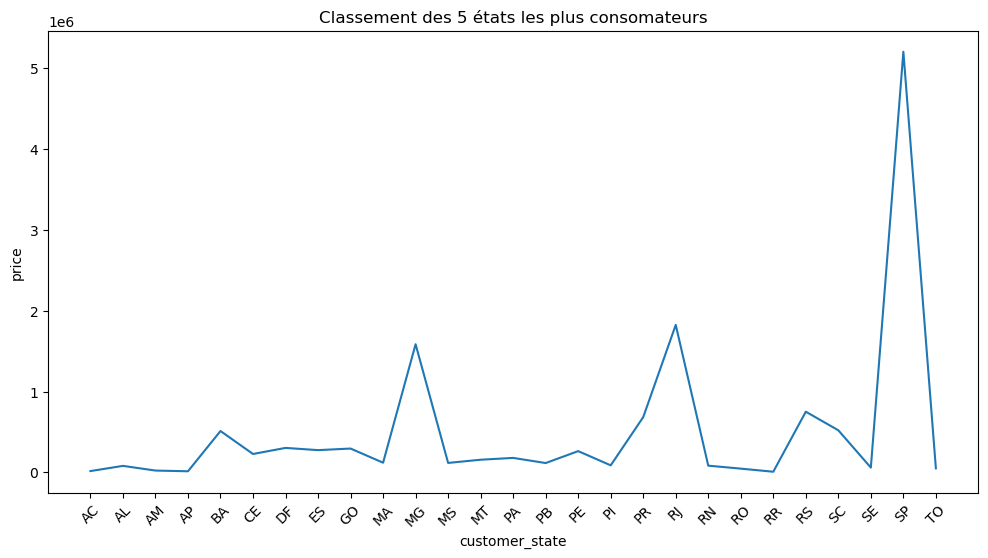

In [12]:
# 4. Visualisation rapide
plt.figure(figsize=(12,6))
sns.lineplot(data=state_revenue, x=state_revenue['customer_state'].astype(str), y='price')
plt.xticks(rotation=45)
plt.title('Classement des 5 états les plus consomateurs')
plt.show()

## Nous allons identifier les clients "Perdus" vs les clients "Récents".

In [14]:
# Un petit coup de main pour le code :
# On définit "Aujourd'hui" comme le jour suivant l'achat le plus récent du dataset
now = customers_details['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = customers_details.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (now - x.max()).days, # Récence
    'order_id': 'nunique',                                     # Fréquence
    'price': 'sum'                                             # Montant
}).rename(columns={
    'order_purchase_timestamp': 'recence',
    'order_id': 'frequence',
    'price': 'montant'
})

print(rfm.head())

                                  recence  frequence  montant
customer_unique_id                                           
0000366f3b9a7992bf8c76cfdf3221e2      116          1   129.90
0000b849f77a49e4a4ce2b2a4ca5be3f      119          1    18.90
0000f46a3911fa3c0805444483337064      542          1    69.00
0000f6ccb0745a6a4b88665a16c9f078      326          1    25.99
0004aac84e0df4da2b147fca70cf8255      293          1   180.00


### Quelle est la moyenne du montant dépensé par client (montant) ? Et subsidiairement : Quel est le montant maximum dépensé par un seul client ?

In [15]:
rfm['montant'].mean()

142.44019807168308

In [16]:
rfm['montant'].max()

13440.0

In [17]:
rfm.sort_values(by='recence', ascending = True)

,recence,frequence,montant
customer_unique_id,,,
ff22e30958c13ffe219db7d711e8f564,1,2,290.00
b4dcade04bc548b7e3b0243c801f8c26,5,1,99.00
7a22d14aa3c3599238509ddca4b93b01,5,1,63.90
0421e7a23f21e5d54efed456aedbc513,5,1,109.90
24ac2b4327e25baf39f2119e4228976a,5,1,84.99
...,...,...,...
2f64e403852e6893ae37485d5fcacdaf,700,1,21.90
0eb1ee9dba87f5b36b4613a65074337c,701,1,100.00
830d5b7aaa3b6f1e9ad63703bec97d23,718,1,134.97


## Étape 5 : Analyse "Assurance & Risque" - Les Délais de Livraison

In [21]:
# On s'assure d'abord qu'on ne travaille que sur les commandes livrées
delivered_orders = orders.dropna(subset=['order_delivered_customer_date']).copy()

# Calcul de la différence en jours
delivered_orders['retard'] = (delivered_orders['order_delivered_customer_date'] - 
                              delivered_orders['order_estimated_delivery_date']).dt.days

# On ne garde que les retards positifs (retard > 0)
# Si le chiffre est négatif, c'est que le colis est arrivé en avance !
orders_late = delivered_orders[delivered_orders['retard'] > 0]

In [22]:
nb_retards = len(orders_late)
total_commandes = len(delivered_orders)
pourcentage_retard = (nb_retards / total_commandes) * 100

retard_max = delivered_orders['retard'].max()

print(f"Pourcentage de retards : {pourcentage_retard:.2f}%")
print(f"Retard maximum : {retard_max} jours")

Pourcentage de retards : 6.77%
Retard maximum : 188 jours


In [ ]:
## Étape 6 : Analyse "Produits & Réputation"

In [ ]:
# L'objectif : Prouver mathématiquement que le retard de livraison est le premier facteur d'une mauvaise note.

In [24]:
# Charger les avis
reviews = pd.read_csv('/Users/GermainMbila/Documents/Projets/Projets 2026/Dataset Olist (Retail:Marketing)/olist_order_reviews_dataset.csv')

# Fusionner les commandes (avec notre colonne retard) et les avis
# On utilise 'delivered_orders' qu'on a créé à l'étape précédente
df_analysis = pd.merge(delivered_orders, reviews, on='order_id')

# Créer une colonne binaire : "En Retard" (True/False)
df_analysis['is_late'] = df_analysis['retard'] > 0
df_analysis['is_late']

0        False
1        False
2        False
3        False
4        False
         ...  
96354    False
96355    False
96356    False
96357    False
96358    False
Name: is_late, Length: 96359, dtype: bool

In [25]:
# Calculer la moyenne des notes selon le statut de livraison
statut_satisfaction = df_analysis.groupby('is_late')['review_score'].mean()

print("Note moyenne selon le statut de livraison :")
print(statut_satisfaction)

Note moyenne selon le statut de livraison :
is_late
False    4.289842
True     2.271139
Name: review_score, dtype: float64


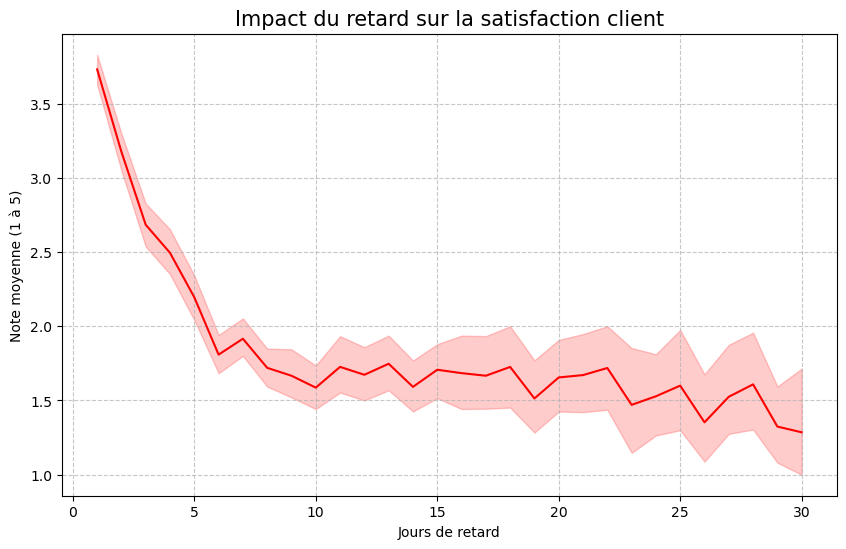

In [26]:
plt.figure(figsize=(10,6))

# On filtre pour ne voir que les retards entre 1 et 30 jours pour la clarté
retards_30j = df_analysis[(df_analysis['retard'] > 0) & (df_analysis['retard'] <= 30)]

sns.lineplot(data=retards_30j, x='retard', y='review_score', color='red')

plt.title('Impact du retard sur la satisfaction client', fontsize=15)
plt.xlabel('Jours de retard')
plt.ylabel('Note moyenne (1 à 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [27]:
statut_satisfaction.head()

is_late
False    4.289842
True     2.271139
Name: review_score, dtype: float64

In [28]:
## Étape 8 : Analyse "Finance & Assurance" - Le coût du risque

In [ ]:
# On va calculer combien de "Chiffre d'Affaires à Risque" Olist génère à cause des retards.

In [29]:
# 1. Fusionner avec la table items pour avoir les montants
df_finance = pd.merge(df_analysis, items[['order_id', 'price']], on='order_id')

# 2. Isoler les commandes qui cumulent Retard ET Note de 1
ca_a_risque = df_finance[(df_finance['is_late'] == True) & (df_finance['review_score'] == 1)]['price'].sum()

# 3. Calculer le CA total pour comparer
ca_total = df_finance['price'].sum()

print(f"Chiffre d'affaires à haut risque (Retard + Note 1) : {ca_a_risque:,.2f} BRL")
print(f"Pourcentage du CA total menacé : {(ca_a_risque / ca_total) * 100:.2f}%")

Chiffre d'affaires à haut risque (Retard + Note 1) : 546,359.75 BRL
Pourcentage du CA total menacé : 4.15%


In [ ]:
## Étape 9 : Spécialisation "Retail & Marketing"

## Pour terminer cette session, identifions quelles catégories de produits sont les plus fragiles face au retard. Est-ce que les gens sont plus en colère quand leur smartphone est en retard que lorsqu'il s'agit d'un tapis ?

In [35]:
# 1. Joindre les analyses de retard avec les items (pour avoir le product_id)
df_temp = pd.merge(df_analysis, items[['order_id', 'product_id', 'price']], on='order_id')

# 2. Joindre avec la table products (pour avoir le nom de la catégorie)
# On charge d'abord la table products
products = pd.read_csv('/Users/GermainMbila/Documents/Projets/Projets 2026/Dataset Olist (Retail:Marketing)/olist_products_dataset.csv')

df_final = pd.merge(df_temp, products[['product_id', 'product_category_name']], on='product_id')

# 3. Filtrer sur les retards et compter
top_retards_cat = df_final[df_final['is_late'] == True]['product_category_name'].value_counts().head(5)

print("Top 5 des catégories avec le plus de retards :")
print(top_retards_cat)

Top 5 des catégories avec le plus de retards :
product_category_name
cama_mesa_banho           757
beleza_saude              699
moveis_decoracao          560
esporte_lazer             523
informatica_acessorios    486
Name: count, dtype: int64


Retail : "J'ai identifié que le linge de maison est la catégorie la plus critique en termes de logistique. J'ai recommandé une réévaluation des prestataires de transport pour ces articles volumineux afin de protéger le volume de ventes."

Marketing : "Grâce à la segmentation et l'analyse des avis, j'ai prouvé que le retard divise la satisfaction client par deux (de 4.3 à 2.2). J'ai suggéré de suspendre les campagnes d'acquisition sur les segments à fort retard pour éviter de détériorer la LTV (Life Time Value)."

Finance/Assurance : "J'ai quantifié le 'Chiffre d'Affaires à risque' en isolant les transactions cumulant retard et note de 1/5, permettant de mieux provisionner les coûts liés aux litiges et aux remboursements."